# Imports and Functions

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.feature_selection import VarianceThreshold

path = r'filtered and normalised all descriptor data.csv'
df = pd.read_csv(path)
data_df = df.drop(columns=['Target', 'Refcode', 'Point group'])

In [ ]:
def correlation_func(filepath, targetcolumn, threshold):
    df = pd.read_csv(filepath)
    df = df.drop(columns=['Refcode', 'Point group'])
    matrix = df.corr()
    target_correlations = matrix[targetcolumn]
    target_correlations = target_correlations.drop(labels=[targetcolumn])

    selected_columns = []
    for feature, correlation in target_correlations.items():
        if correlation > threshold:
            selected_columns.append(feature)
        elif correlation < -threshold:
            selected_columns.append(feature)
    
    selected_columns.append(targetcolumn)
    filtered_df = df[selected_columns]
    
    return filtered_df

correlated_df = correlation_func(path, 'Target', 0.1)
correlated_df

In [4]:
def correlation_func_list(filepath, targetcolumn, threshold):
    df = pd.read_csv(filepath)
    df = df.drop(columns=['Refcode', 'Point group'])
    matrix = df.corr()
    target_correlations = matrix[targetcolumn]
    target_correlations = target_correlations.drop(labels=[targetcolumn])
    print(target_correlations)

correlation_func_list(path, 'Target', 0.1)

Number of atoms                                 0.061222
Number of bonds                                 0.056865
Number of heavy atoms                           0.036139
Number of heteroatoms                          -0.134992
Number of rings                                -0.006167
Number of aromatic rings                        0.093769
Number of sp3 hybridised carbons               -0.008422
Asphericity                                     0.103792
Eccentricity                                    0.109620
Internal Shape Factor                           0.000976
Normalised principle moment ratio 1            -0.122995
Normalised principle moment ratio 2            -0.037257
First (smallest) principle moment of inertia   -0.033866
Second principle moment of inertias             0.058872
Third (largest) principle moment of inertia     0.070180
Radius of Gyration                              0.084967
Molecule Sphericity Index                      -0.133769
Plane of best fit              

---
# Comparing Generation 1

In [ ]:
# Necessary imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import GridSearchCV

# Load the data
list_path = r'filtered and normalised all descriptor data.csv'
df = pd.read_csv(list_path)

# Clean the data
df_cleaned = df.drop(columns=['Point group', 'Refcode'])
feature_df = df_cleaned.drop(columns=['Target'])

# Convert to numpy arrays
X = np.asarray(feature_df)
y = np.asarray(df_cleaned['Target'])

# Parameter grid for GridSearchCV
param_grid = [
    {'C': [0.5, 1, 10, 100],
     'gamma': ['scale', 1, 0.1, 0.01, 0.001, 0.0001],
     'kernel': ['rbf', 'linear', 'poly']}
]

# Initialize variables to store results
accuracies = []
confusion_matrices = []

# Run the model 100 times
for _ in range(100):
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)
    
    # Perform grid search to find optimal parameters
    optimal_params = GridSearchCV(
        SVC(),
        param_grid,
        cv=5,
        scoring='accuracy',
        verbose=0
    )
    optimal_params.fit(X_train, y_train)
    
    # Train the classifier with the best parameters
    classifier = optimal_params.best_estimator_
    classifier.fit(X_train, y_train)
    
    # Make predictions
    y_predict = classifier.predict(X_test)
    
    # Calculate accuracy
    accuracy = metrics.accuracy_score(y_test, y_predict) * 100
    accuracies.append(accuracy)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_predict)
    confusion_matrices.append(cm)

    print(f'Run {_+1} completed with accuracy: {accuracy}')

# Calculate the average accuracy
average_accuracy = np.mean(accuracies)

# Find the best confusion matrix (highest accuracy)
best_accuracy_index = np.argmax(accuracies)
best_confusion_matrix = confusion_matrices[best_accuracy_index]
best_accuracy = accuracies[best_accuracy_index]

# Calculate the average confusion matrix
average_confusion_matrix = np.mean(confusion_matrices, axis=0)

# Display the best confusion matrix
ConfusionMatrixDisplay(best_confusion_matrix, display_labels=["Sohncke", "Racemic"]).plot(cmap=plt.cm.Blues, values_format='d')
plt.title(f'SVM: Best Confusion Matrix without High Correlated Descriptors [Accuracy: {best_accuracy:.2f}%]')
plt.show()

# Display the average confusion matrix
ConfusionMatrixDisplay(average_confusion_matrix, display_labels=["Sohncke", "Racemic"]).plot(cmap=plt.cm.Blues, values_format='.2f')
plt.title('SVM: Average Confusion Matrix without High Correlated Descriptors')
plt.show()

# Print the average accuracy
print(f"Average Accuracy over 100 runs: {average_accuracy:.2f}%")

Run 1 completed with accuracy: 81.66666666666667
Run 2 completed with accuracy: 81.66666666666667
Run 3 completed with accuracy: 90.0
Run 4 completed with accuracy: 81.66666666666667
Run 5 completed with accuracy: 81.66666666666667
Run 6 completed with accuracy: 83.33333333333334
Run 7 completed with accuracy: 83.33333333333334
Run 8 completed with accuracy: 91.66666666666666
Run 9 completed with accuracy: 88.33333333333333
Run 10 completed with accuracy: 83.33333333333334
Run 11 completed with accuracy: 80.0
Run 12 completed with accuracy: 85.0
Run 13 completed with accuracy: 75.0
Run 14 completed with accuracy: 78.33333333333333
Run 15 completed with accuracy: 85.0
Run 16 completed with accuracy: 86.66666666666667
Run 17 completed with accuracy: 90.0
Run 18 completed with accuracy: 86.66666666666667
Run 19 completed with accuracy: 83.33333333333334
Run 20 completed with accuracy: 81.66666666666667
Run 21 completed with accuracy: 85.0
Run 22 completed with accuracy: 80.0
Run 23 comple

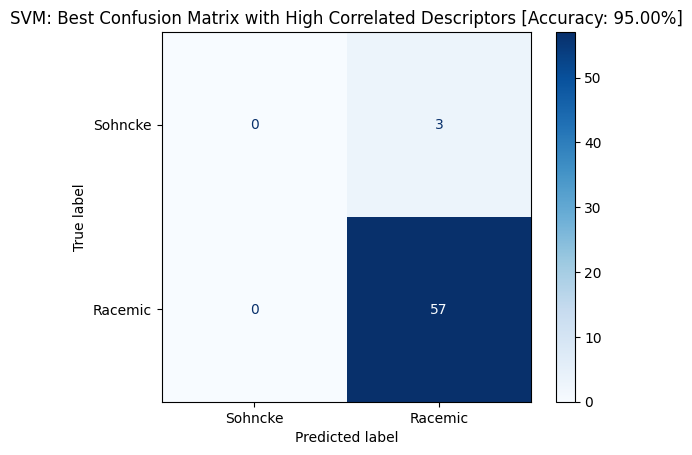

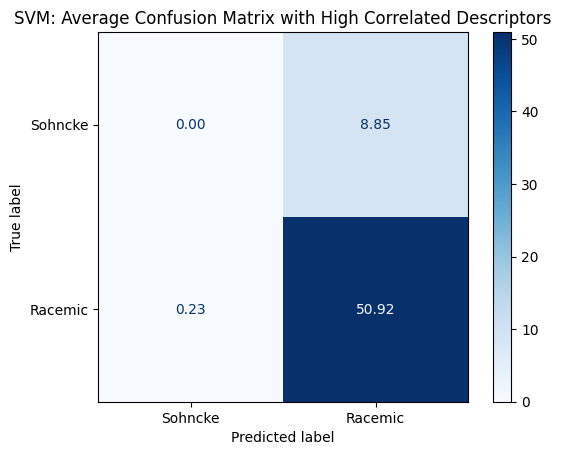

Average Accuracy over 100 runs: 84.87%


In [ ]:
# Necessary imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import GridSearchCV

# Load the data
list_path = r'filtered and normalised all descriptor data.csv'

# Clean the data
df_cleaned = correlated_df
feature_df = df_cleaned.drop(columns=['Target'])

# Convert to numpy arrays
X = np.asarray(feature_df)
y = np.asarray(df_cleaned['Target'])

# Parameter grid for GridSearchCV
param_grid = [
    {'C': [0.5, 1, 10, 100],
     'gamma': ['scale', 1, 0.1, 0.01, 0.001, 0.0001],
     'kernel': ['rbf', 'linear', 'poly']}
]

# Initialize variables to store results
accuracies = []
confusion_matrices = []

# Run the model 100 times
for _ in range(100):
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)
    
    # Perform grid search to find optimal parameters
    optimal_params = GridSearchCV(
        SVC(),
        param_grid,
        cv=5,
        scoring='accuracy',
        verbose=0
    )
    optimal_params.fit(X_train, y_train)
    
    # Train the classifier with the best parameters
    classifier = optimal_params.best_estimator_
    classifier.fit(X_train, y_train)
    
    # Make predictions
    y_predict = classifier.predict(X_test)
    
    # Calculate accuracy
    accuracy = metrics.accuracy_score(y_test, y_predict) * 100
    accuracies.append(accuracy)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_predict)
    confusion_matrices.append(cm)

    print(f'Run {_+1} completed with accuracy: {accuracy}')

# Calculate the average accuracy
average_accuracy = np.mean(accuracies)

# Find the best confusion matrix (highest accuracy)
best_accuracy_index = np.argmax(accuracies)
best_confusion_matrix = confusion_matrices[best_accuracy_index]
best_accuracy = accuracies[best_accuracy_index]

# Calculate the average confusion matrix
average_confusion_matrix = np.mean(confusion_matrices, axis=0)

# Display the best confusion matrix
ConfusionMatrixDisplay(best_confusion_matrix, display_labels=["Sohncke", "Racemic"]).plot(cmap=plt.cm.Blues, values_format='d')
plt.title(f'SVM: Best Confusion Matrix with High Correlated Descriptors [Accuracy: {best_accuracy:.2f}%]')
plt.show()

# Display the average confusion matrix
ConfusionMatrixDisplay(average_confusion_matrix, display_labels=["Sohncke", "Racemic"]).plot(cmap=plt.cm.Blues, values_format='.2f')
plt.title('SVM: Average Confusion Matrix with High Correlated Descriptors')
plt.show()

# Print the average accuracy
print(f"Average Accuracy over 100 runs: {average_accuracy:.2f}%")

Not much difference in Generation 1 but I wasn't expecting there to be. This generation only ever predicted racemic so it is more about luck than the model actually performing or not.

---
# Comparing Generation 2.1

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [21]:
# Filepath to the dataset
filepath = r'filtered and normalised all descriptor data.csv'

# Number of iterations
num_iterations = 50

# Initialize cumulative accuracy
cumulative_accuracy = 0

for i in range(num_iterations):
    # Load the dataset
    df = pd.read_csv(filepath)

    # Balancing the dataset
    df_target_0 = df[df['Target'] == 0.0]
    df_target_1 = df[df['Target'] == 1.0]
    rows_df_target_0 = df_target_0.shape[0]
    rows_df_target_1 = df_target_1.shape[0]

    if rows_df_target_0 < rows_df_target_1:
        smaller_df = df_target_0
        larger_df = df_target_1
        smaller_rows = rows_df_target_0
    else:
        smaller_df = df_target_1
        larger_df = df_target_0
        smaller_rows = rows_df_target_1

    scaled_larger_df = larger_df.sample(n=smaller_rows)
    balanced_df = pd.concat([smaller_df, scaled_larger_df], axis=0)
    shuffled_balanced_df = balanced_df.sample(frac=1).reset_index(drop=True)

    # Clean the DataFrame
    shuffled_balanced_cleaned_df = shuffled_balanced_df.drop(columns=['Point group', 'Refcode'])

    # Separate features and target
    feature_df = shuffled_balanced_cleaned_df.drop(columns=['Target'])
    X = np.asarray(feature_df)
    y = np.asarray(shuffled_balanced_cleaned_df['Target'])

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

    # Perform GridSearchCV to find the optimal parameters
    param_grid = [
        {'C': [0.5, 1, 10, 100],
         'gamma': ['scale', 1, 0.1, 0.01, 0.001, 0.0001],
         'kernel': ['rbf', 'linear', 'poly']}
    ]

    optimal_params = GridSearchCV(
        SVC(),
        param_grid,
        cv=5,
        scoring='accuracy',
        verbose=0
    )

    optimal_params.fit(X_train, y_train)

    # Get the best estimator and fit the model
    classifier = optimal_params.best_estimator_
    classifier.fit(X_train, y_train)

    # Predict the test set
    y_predict = classifier.predict(X_test)

    # Calculate the accuracy
    accuracy = metrics.accuracy_score(y_test, y_predict)
    cumulative_accuracy += accuracy

    # Optionally, print the iteration number and accuracy for tracking progress
    print(f'Iteration {i+1}: Accuracy = {accuracy * 100:.2f}%')

# Calculate the average accuracy
average_accuracy = (cumulative_accuracy / num_iterations) * 100
print(f'Average Accuracy over {num_iterations} iterations: {average_accuracy:.2f}%')

# # Optionally, display the confusion matrix for the last iteration
# ConfusionMatrixDisplay.from_estimator(
#     classifier,
#     X_test,
#     y_test,
#     display_labels=["Sohncke", "Racemic"],
#     cmap=plt.cm.Blues,
#     values_format='d'
# )
# plt.title(f'Confusion Matrix (Iteration {num_iterations})')
# plt.show()


Iteration 1: Accuracy = 50.00%
Iteration 2: Accuracy = 34.62%
Iteration 3: Accuracy = 46.15%
Iteration 4: Accuracy = 53.85%
Iteration 5: Accuracy = 65.38%
Iteration 6: Accuracy = 57.69%
Iteration 7: Accuracy = 53.85%
Iteration 8: Accuracy = 57.69%
Iteration 9: Accuracy = 42.31%
Iteration 10: Accuracy = 46.15%
Iteration 11: Accuracy = 57.69%
Iteration 12: Accuracy = 42.31%
Iteration 13: Accuracy = 46.15%
Iteration 14: Accuracy = 53.85%
Iteration 15: Accuracy = 53.85%
Iteration 16: Accuracy = 38.46%
Iteration 17: Accuracy = 38.46%
Iteration 18: Accuracy = 50.00%
Iteration 19: Accuracy = 50.00%
Iteration 20: Accuracy = 53.85%
Iteration 21: Accuracy = 53.85%
Iteration 22: Accuracy = 46.15%
Iteration 23: Accuracy = 34.62%
Iteration 24: Accuracy = 38.46%
Iteration 25: Accuracy = 50.00%
Iteration 26: Accuracy = 57.69%
Iteration 27: Accuracy = 46.15%
Iteration 28: Accuracy = 38.46%
Iteration 29: Accuracy = 50.00%
Iteration 30: Accuracy = 53.85%
Iteration 31: Accuracy = 57.69%
Iteration 32: Acc

In [22]:
# Number of iterations
num_iterations = 50

# Initialize cumulative accuracy
cumulative_accuracy = 0

for i in range(num_iterations):
    # Load the dataset
    df = correlated_df

    # Balancing the dataset
    df_target_0 = df[df['Target'] == 0.0]
    df_target_1 = df[df['Target'] == 1.0]
    rows_df_target_0 = df_target_0.shape[0]
    rows_df_target_1 = df_target_1.shape[0]

    if rows_df_target_0 < rows_df_target_1:
        smaller_df = df_target_0
        larger_df = df_target_1
        smaller_rows = rows_df_target_0
    else:
        smaller_df = df_target_1
        larger_df = df_target_0
        smaller_rows = rows_df_target_1

    scaled_larger_df = larger_df.sample(n=smaller_rows)
    balanced_df = pd.concat([smaller_df, scaled_larger_df], axis=0)
    shuffled_balanced_df = balanced_df.sample(frac=1).reset_index(drop=True)

    # Separate features and target
    feature_df = shuffled_balanced_df.drop(columns=['Target'])
    X = np.asarray(feature_df)
    y = np.asarray(shuffled_balanced_df['Target'])

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

    # Perform GridSearchCV to find the optimal parameters
    param_grid = [
        {'C': [0.5, 1, 10, 100],
         'gamma': ['scale', 1, 0.1, 0.01, 0.001, 0.0001],
         'kernel': ['rbf', 'linear', 'poly']}
    ]

    optimal_params = GridSearchCV(
        SVC(),
        param_grid,
        cv=5,
        scoring='accuracy',
        verbose=0
    )

    optimal_params.fit(X_train, y_train)

    # Get the best estimator and fit the model
    classifier = optimal_params.best_estimator_
    classifier.fit(X_train, y_train)

    # Predict the test set
    y_predict = classifier.predict(X_test)

    # Calculate the accuracy
    accuracy = metrics.accuracy_score(y_test, y_predict)
    cumulative_accuracy += accuracy

    # Optionally, print the iteration number and accuracy for tracking progress
    print(f'Iteration {i+1}: Accuracy = {accuracy * 100:.2f}%')

# Calculate the average accuracy
average_accuracy = (cumulative_accuracy / num_iterations) * 100
print(f'Average Accuracy over {num_iterations} iterations: {average_accuracy:.2f}%')

# # Optionally, display the confusion matrix for the last iteration
# ConfusionMatrixDisplay.from_estimator(
#     classifier,
#     X_test,
#     y_test,
#     display_labels=["Sohncke", "Racemic"],
#     cmap=plt.cm.Blues,
#     values_format='d'
# )
# plt.title(f'Confusion Matrix (Iteration {num_iterations})')
# plt.show()


Iteration 1: Accuracy = 57.69%
Iteration 2: Accuracy = 57.69%
Iteration 3: Accuracy = 50.00%
Iteration 4: Accuracy = 53.85%
Iteration 5: Accuracy = 53.85%
Iteration 6: Accuracy = 57.69%
Iteration 7: Accuracy = 61.54%
Iteration 8: Accuracy = 38.46%
Iteration 9: Accuracy = 46.15%
Iteration 10: Accuracy = 57.69%
Iteration 11: Accuracy = 42.31%
Iteration 12: Accuracy = 53.85%
Iteration 13: Accuracy = 61.54%
Iteration 14: Accuracy = 53.85%
Iteration 15: Accuracy = 61.54%
Iteration 16: Accuracy = 42.31%
Iteration 17: Accuracy = 65.38%
Iteration 18: Accuracy = 50.00%
Iteration 19: Accuracy = 57.69%
Iteration 20: Accuracy = 50.00%
Iteration 21: Accuracy = 53.85%
Iteration 22: Accuracy = 57.69%
Iteration 23: Accuracy = 46.15%
Iteration 24: Accuracy = 65.38%
Iteration 25: Accuracy = 61.54%
Iteration 26: Accuracy = 50.00%
Iteration 27: Accuracy = 69.23%
Iteration 28: Accuracy = 53.85%
Iteration 29: Accuracy = 57.69%
Iteration 30: Accuracy = 42.31%
Iteration 31: Accuracy = 53.85%
Iteration 32: Acc

47.85% increased to 53.69%

---

# SVM Gen 3

## Small Dataset

Run 1: Accuracy = 53.85%
Run 2: Accuracy = 57.69%
Run 3: Accuracy = 69.23%
Run 4: Accuracy = 61.54%
Run 5: Accuracy = 61.54%
Run 6: Accuracy = 46.15%
Run 7: Accuracy = 61.54%
Run 8: Accuracy = 53.85%
Run 9: Accuracy = 50.00%
Run 10: Accuracy = 57.69%
Run 11: Accuracy = 38.46%
Run 12: Accuracy = 57.69%
Run 13: Accuracy = 50.00%
Run 14: Accuracy = 53.85%
Run 15: Accuracy = 61.54%
Run 16: Accuracy = 69.23%
Run 17: Accuracy = 57.69%
Run 18: Accuracy = 57.69%
Run 19: Accuracy = 50.00%
Run 20: Accuracy = 73.08%
Run 21: Accuracy = 50.00%
Run 22: Accuracy = 53.85%
Run 23: Accuracy = 57.69%
Run 24: Accuracy = 61.54%
Run 25: Accuracy = 65.38%
Run 26: Accuracy = 46.15%
Run 27: Accuracy = 53.85%
Run 28: Accuracy = 57.69%
Run 29: Accuracy = 30.77%
Run 30: Accuracy = 61.54%
Run 31: Accuracy = 38.46%
Run 32: Accuracy = 57.69%
Run 33: Accuracy = 57.69%
Run 34: Accuracy = 57.69%
Run 35: Accuracy = 61.54%
Run 36: Accuracy = 69.23%
Run 37: Accuracy = 46.15%
Run 38: Accuracy = 65.38%
Run 39: Accuracy = 61

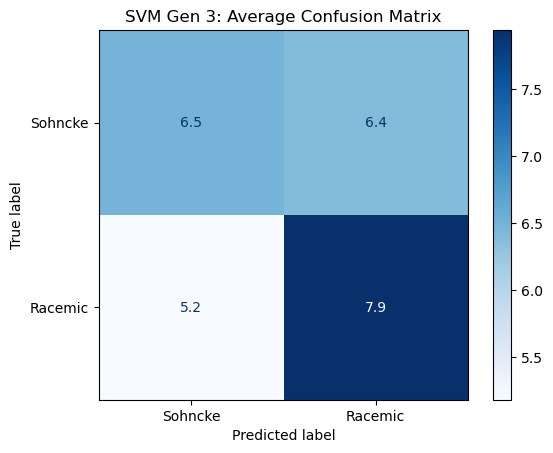

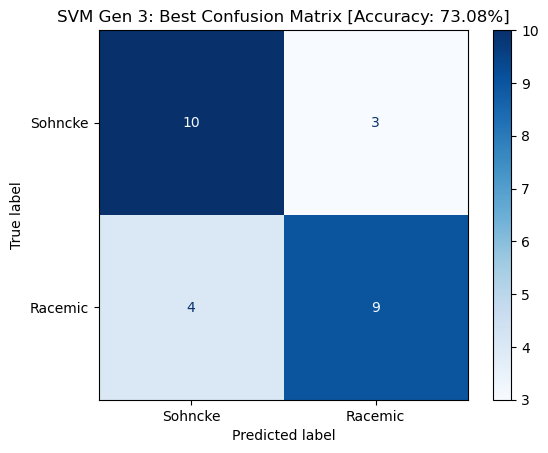

Best Accuracy: 73.08%


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import pickle

# Number of iterations
num_iterations = 100

# Initialize cumulative accuracy and variables to track the best model and confusion matrix
cumulative_accuracy = 0
best_accuracy = 0
best_confusion_matrix = None
all_confusion_matrices = []

for i in range(num_iterations):
    # Load the dataset
    df = correlated_df

    # Balancing the dataset
    df_target_0 = df[df['Target'] == 0.0]
    df_target_1 = df[df['Target'] == 1.0]
    rows_df_target_0 = df_target_0.shape[0]
    rows_df_target_1 = df_target_1.shape[0]

    if rows_df_target_0 < rows_df_target_1:
        smaller_df = df_target_0
        larger_df = df_target_1
        smaller_rows = rows_df_target_0
    else:
        smaller_df = df_target_1
        larger_df = df_target_0
        smaller_rows = rows_df_target_1

    scaled_larger_df = larger_df.sample(n=smaller_rows)
    balanced_df = pd.concat([smaller_df, scaled_larger_df], axis=0)
    shuffled_balanced_df = balanced_df.sample(frac=1).reset_index(drop=True)

    # Separate features and target
    feature_df = shuffled_balanced_df.drop(columns=['Target'])
    X = np.asarray(feature_df)
    y = np.asarray(shuffled_balanced_df['Target'])

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

    # Perform GridSearchCV to find the optimal parameters
    param_grid = [
        {'C': [0.5, 1, 10, 100],
         'gamma': ['scale', 1, 0.1, 0.01, 0.001, 0.0001],
         'kernel': ['rbf', 'linear', 'poly']}
    ]

    optimal_params = GridSearchCV(
        SVC(),
        param_grid,
        cv=5,
        scoring='accuracy',
        verbose=0
    )

    optimal_params.fit(X_train, y_train)

    # Get the best estimator and fit the model
    classifier = optimal_params.best_estimator_
    classifier.fit(X_train, y_train)

    # Predict the test set
    y_predict = classifier.predict(X_test)

    # Calculate the accuracy
    accuracy = metrics.accuracy_score(y_test, y_predict)
    cumulative_accuracy += accuracy

    # Calculate the confusion matrix for this run
    cm = confusion_matrix(y_test, y_predict)
    all_confusion_matrices.append(cm)

    # Check if this is the best model so far
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_confusion_matrix = cm
        best_model = classifier

    # Print the iteration number and accuracy
    print(f'Run {i+1}: Accuracy = {accuracy * 100:.2f}%')

# Calculate the average accuracy
average_accuracy = (cumulative_accuracy / num_iterations) * 100
print(f'Average Accuracy over {num_iterations} iterations: {average_accuracy:.2f}%')

# Calculate the average confusion matrix
average_confusion_matrix = np.mean(all_confusion_matrices, axis=0)

# Display the average confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=average_confusion_matrix,
                              display_labels=["Sohncke", "Racemic"])
disp.plot(cmap=plt.cm.Blues)
plt.title(f'SVM Gen 3: Average Confusion Matrix')
plt.show()

# Display the best confusion matrix
best_disp = ConfusionMatrixDisplay(confusion_matrix=best_confusion_matrix,
                                   display_labels=["Sohncke", "Racemic"])
best_disp.plot(cmap=plt.cm.Blues)
plt.title(f'SVM Gen 3: Best Confusion Matrix [Accuracy: {best_accuracy * 100:.2f}%]')
plt.show()

# Save the best model as a pickle file
with open('best_svm_model_gen_3.pkl', 'wb') as file:
    pickle.dump(best_model, file)

print(f'Best Accuracy: {best_accuracy * 100:.2f}%')


## Full Dataset

Run 1: Accuracy = 87.78%
Run 2: Accuracy = 85.56%
Run 3: Accuracy = 84.44%
Run 4: Accuracy = 84.44%
Run 5: Accuracy = 83.33%
Run 6: Accuracy = 82.22%
Run 7: Accuracy = 87.78%
Run 8: Accuracy = 87.78%
Run 9: Accuracy = 82.22%
Run 10: Accuracy = 83.33%
Run 11: Accuracy = 84.44%
Run 12: Accuracy = 83.33%
Run 13: Accuracy = 86.67%
Run 14: Accuracy = 86.67%
Run 15: Accuracy = 88.89%
Run 16: Accuracy = 86.67%
Run 17: Accuracy = 86.67%
Run 18: Accuracy = 84.44%
Run 19: Accuracy = 83.33%
Run 20: Accuracy = 82.22%
Run 21: Accuracy = 81.11%
Run 22: Accuracy = 86.67%
Run 23: Accuracy = 81.11%
Run 24: Accuracy = 94.44%
Run 25: Accuracy = 87.78%
Run 26: Accuracy = 85.56%
Run 27: Accuracy = 91.11%
Run 28: Accuracy = 82.22%
Run 29: Accuracy = 86.67%
Run 30: Accuracy = 82.22%
Run 31: Accuracy = 78.89%
Run 32: Accuracy = 84.44%
Run 33: Accuracy = 80.00%
Run 34: Accuracy = 85.56%
Run 35: Accuracy = 86.67%
Run 36: Accuracy = 78.89%
Run 37: Accuracy = 83.33%
Run 38: Accuracy = 85.56%
Run 39: Accuracy = 83

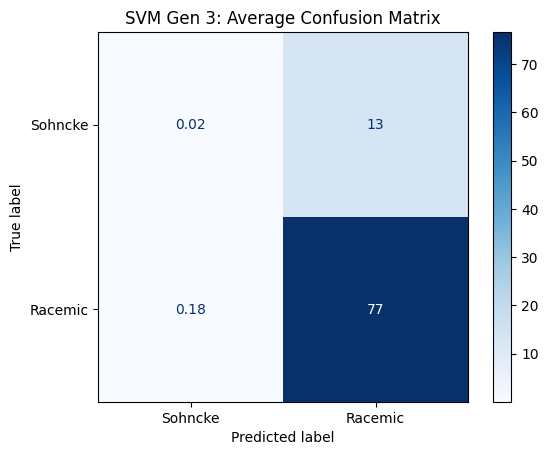

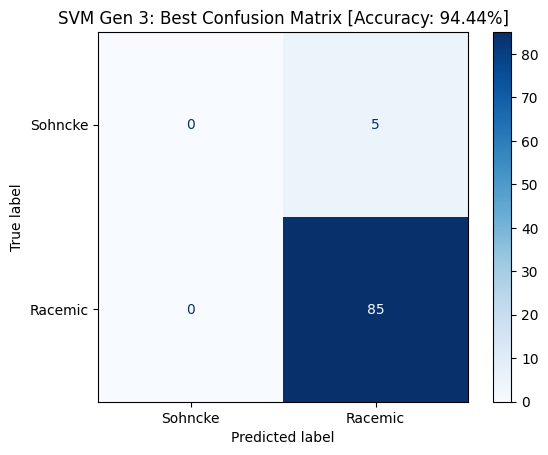

Best Accuracy: 94.44%


In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import pickle

# Number of iterations
num_iterations = 100

# Initialize cumulative accuracy and variables to track the best model and confusion matrix
cumulative_accuracy = 0
best_accuracy = 0
best_confusion_matrix = None
all_confusion_matrices = []

for i in range(num_iterations):
    # Clean the data
    cleaned_df = correlated_df
    
    # Separate features and target
    X = np.asarray(cleaned_df.drop(columns=['Target']))
    y = np.asarray(cleaned_df['Target'])

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

    # Perform GridSearchCV to find the optimal parameters
    param_grid = [
        {'C': [0.5, 1, 10, 100],
         'gamma': ['scale', 1, 0.1, 0.01, 0.001, 0.0001],
         'kernel': ['rbf', 'linear', 'poly']}
    ]

    optimal_params = GridSearchCV(
        SVC(),
        param_grid,
        cv=5,
        scoring='accuracy',
        verbose=0
    )

    optimal_params.fit(X_train, y_train)

    # Get the best estimator and fit the model
    classifier = optimal_params.best_estimator_
    classifier.fit(X_train, y_train)

    # Predict the test set
    y_predict = classifier.predict(X_test)

    # Calculate the accuracy
    accuracy = metrics.accuracy_score(y_test, y_predict)
    cumulative_accuracy += accuracy

    # Calculate the confusion matrix for this run
    cm = confusion_matrix(y_test, y_predict)
    all_confusion_matrices.append(cm)

    # Check if this is the best model so far
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_confusion_matrix = cm
        best_model = classifier

    # Print the iteration number and accuracy
    print(f'Run {i+1}: Accuracy = {accuracy * 100:.2f}%')

# Calculate the average accuracy
average_accuracy = (cumulative_accuracy / num_iterations) * 100
print(f'Average Accuracy over {num_iterations} iterations: {average_accuracy:.2f}%')

# Calculate the average confusion matrix
average_confusion_matrix = np.mean(all_confusion_matrices, axis=0)

# Display the average confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=average_confusion_matrix,
                              display_labels=["Sohncke", "Racemic"])
disp.plot(cmap=plt.cm.Blues)
plt.title(f'SVM Gen 3: Average Confusion Matrix')
plt.show()

# Display the best confusion matrix
best_disp = ConfusionMatrixDisplay(confusion_matrix=best_confusion_matrix,
                                   display_labels=["Sohncke", "Racemic"])
best_disp.plot(cmap=plt.cm.Blues)
plt.title(f'SVM Gen 3: Best Confusion Matrix [Accuracy: {best_accuracy * 100:.2f}%]')
plt.show()

# Save the best model as a pickle file
with open('best_svm_model_gen_3_no_bal.pkl', 'wb') as file:
    pickle.dump(best_model, file)

print(f'Best Accuracy: {best_accuracy * 100:.2f}%')

---

# LogReg Gen 3

## Small Dataset

Run 1: Accuracy = 50.00%
Run 2: Accuracy = 50.00%
Run 3: Accuracy = 38.46%
Run 4: Accuracy = 42.31%
Run 5: Accuracy = 57.69%
Run 6: Accuracy = 53.85%
Run 7: Accuracy = 65.38%
Run 8: Accuracy = 46.15%
Run 9: Accuracy = 42.31%
Run 10: Accuracy = 42.31%
Run 11: Accuracy = 50.00%
Run 12: Accuracy = 53.85%
Run 13: Accuracy = 57.69%
Run 14: Accuracy = 34.62%
Run 15: Accuracy = 57.69%
Run 16: Accuracy = 50.00%
Run 17: Accuracy = 50.00%
Run 18: Accuracy = 42.31%
Run 19: Accuracy = 42.31%
Run 20: Accuracy = 57.69%
Run 21: Accuracy = 46.15%
Run 22: Accuracy = 73.08%
Run 23: Accuracy = 46.15%
Run 24: Accuracy = 65.38%
Run 25: Accuracy = 50.00%
Run 26: Accuracy = 50.00%
Run 27: Accuracy = 34.62%
Run 28: Accuracy = 65.38%
Run 29: Accuracy = 50.00%
Run 30: Accuracy = 50.00%
Run 31: Accuracy = 42.31%
Run 32: Accuracy = 73.08%
Run 33: Accuracy = 50.00%
Run 34: Accuracy = 65.38%
Run 35: Accuracy = 38.46%
Run 36: Accuracy = 65.38%
Run 37: Accuracy = 65.38%
Run 38: Accuracy = 61.54%
Run 39: Accuracy = 42

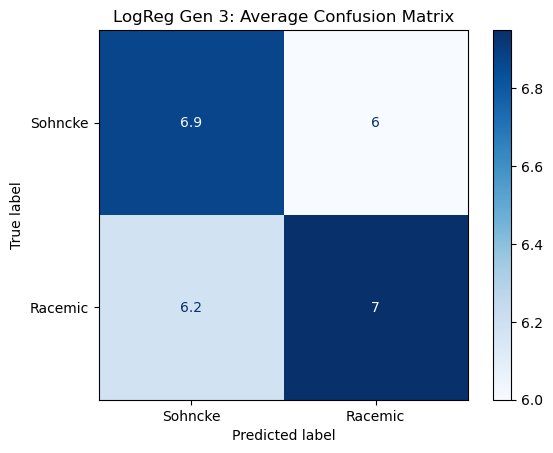

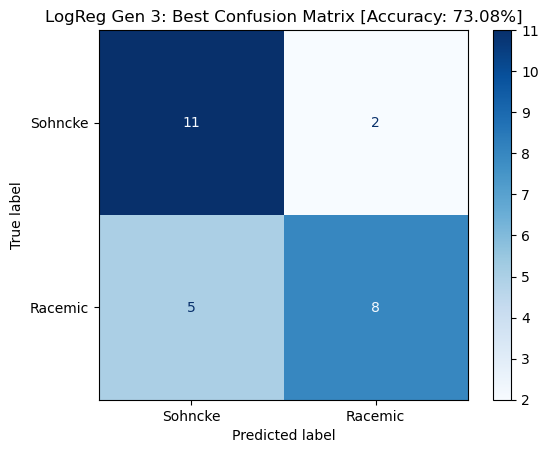

Best Accuracy: 73.08%


In [6]:
# Necessary imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report
import pickle  # Import pickle for saving the model

# Number of iterations
num_iterations = 100

# Initialize cumulative accuracy and variables to track the best model and confusion matrix
cumulative_accuracy = 0
best_accuracy = 0
best_confusion_matrix = None
all_confusion_matrices = []

for i in range(num_iterations):
    # Load the dataset
    df = correlated_df

    # Balancing the dataset
    df_target_0 = df[df['Target'] == 0.0]
    df_target_1 = df[df['Target'] == 1.0]
    rows_df_target_0 = df_target_0.shape[0]
    rows_df_target_1 = df_target_1.shape[0]

    if rows_df_target_0 < rows_df_target_1:
        smaller_df = df_target_0
        larger_df = df_target_1
        smaller_rows = rows_df_target_0
    else:
        smaller_df = df_target_1
        larger_df = df_target_0
        smaller_rows = rows_df_target_1

    scaled_larger_df = larger_df.sample(n=len(smaller_df))  # Sample to balance the dataset
    balanced_df = pd.concat([smaller_df, scaled_larger_df], axis=0).sample(frac=1).reset_index(drop=True)

    # Clean the data
    cleaned_df = balanced_df
    
    # Separate features and target
    X = np.asarray(cleaned_df.drop(columns=['Target']))
    y = np.asarray(cleaned_df['Target'])

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)
    
    logreg = LogisticRegression() # Storing the logistical model
    logreg.fit(X_train, y_train) # Training the logistical model

    y_predict = logreg.predict(X_test) # Predicting sohncke/racemic with the new model

    # Calculate the accuracy
    accuracy = metrics.accuracy_score(y_test, y_predict)
    cumulative_accuracy += accuracy

    # Calculate the confusion matrix for this run
    cm = confusion_matrix(y_test, y_predict)
    all_confusion_matrices.append(cm)

    # Check if this is the best model so far
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_confusion_matrix = cm
        best_model = classifier

    # Print the iteration number and accuracy
    print(f'Run {i+1}: Accuracy = {accuracy * 100:.2f}%')

# Calculate the average accuracy
average_accuracy = (cumulative_accuracy / num_iterations) * 100
print(f'Average Accuracy over {num_iterations} iterations: {average_accuracy:.2f}%')

# Calculate the average confusion matrix
average_confusion_matrix = np.mean(all_confusion_matrices, axis=0)

# Display the average confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=average_confusion_matrix,
                              display_labels=["Sohncke", "Racemic"])
disp.plot(cmap=plt.cm.Blues)
plt.title(f'LogReg Gen 3: Average Confusion Matrix')
plt.show()

# Display the best confusion matrix
best_disp = ConfusionMatrixDisplay(confusion_matrix=best_confusion_matrix,
                                   display_labels=["Sohncke", "Racemic"])
best_disp.plot(cmap=plt.cm.Blues)
plt.title(f'LogReg Gen 3: Best Confusion Matrix [Accuracy: {best_accuracy * 100:.2f}%]')
plt.show()

# Save the best model as a pickle file
with open('best_logistic_regression_model_gen_3.pkl', 'wb') as file:
    pickle.dump(best_model, file)

print(f'Best Accuracy: {best_accuracy * 100:.2f}%')


## Full Dataset

Run 1: Accuracy = 86.67%
Run 2: Accuracy = 86.67%
Run 3: Accuracy = 84.44%
Run 4: Accuracy = 84.44%
Run 5: Accuracy = 88.89%
Run 6: Accuracy = 84.44%
Run 7: Accuracy = 87.78%
Run 8: Accuracy = 90.00%
Run 9: Accuracy = 88.89%
Run 10: Accuracy = 92.22%
Run 11: Accuracy = 90.00%
Run 12: Accuracy = 91.11%
Run 13: Accuracy = 88.89%
Run 14: Accuracy = 86.67%
Run 15: Accuracy = 88.89%
Run 16: Accuracy = 85.56%
Run 17: Accuracy = 84.44%
Run 18: Accuracy = 87.78%
Run 19: Accuracy = 83.33%
Run 20: Accuracy = 85.56%
Run 21: Accuracy = 85.56%
Run 22: Accuracy = 83.33%
Run 23: Accuracy = 82.22%
Run 24: Accuracy = 83.33%
Run 25: Accuracy = 90.00%
Run 26: Accuracy = 92.22%
Run 27: Accuracy = 80.00%
Run 28: Accuracy = 82.22%
Run 29: Accuracy = 82.22%
Run 30: Accuracy = 80.00%
Run 31: Accuracy = 87.78%
Run 32: Accuracy = 90.00%
Run 33: Accuracy = 84.44%
Run 34: Accuracy = 86.67%
Run 35: Accuracy = 82.22%
Run 36: Accuracy = 86.67%
Run 37: Accuracy = 87.78%
Run 38: Accuracy = 92.22%
Run 39: Accuracy = 82

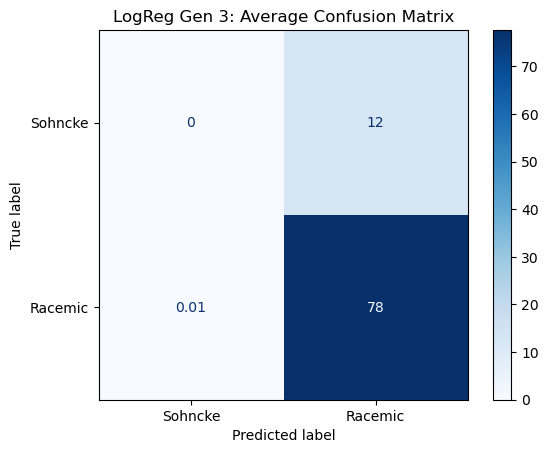

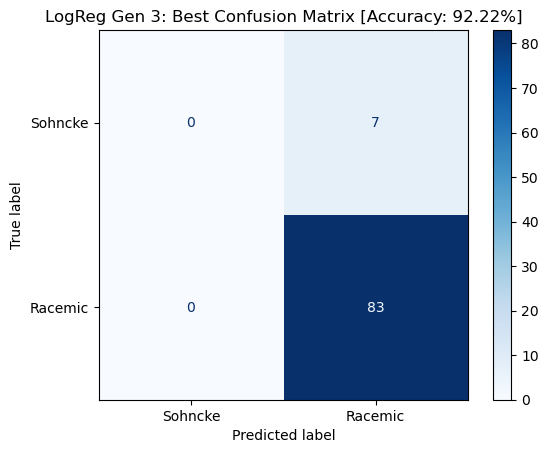

Best Accuracy: 92.22%


In [7]:
# Necessary imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report
import pickle  # Import pickle for saving the model

# Number of iterations
num_iterations = 100

# Initialize cumulative accuracy and variables to track the best model and confusion matrix
cumulative_accuracy = 0
best_accuracy = 0
best_confusion_matrix = None
all_confusion_matrices = []

for i in range(num_iterations):

    # Clean the data
    cleaned_df = correlated_df
    
    # Separate features and target
    X = np.asarray(cleaned_df.drop(columns=['Target']))
    y = np.asarray(cleaned_df['Target'])

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)
    
    logreg = LogisticRegression() # Storing the logistical model
    logreg.fit(X_train, y_train) # Training the logistical model

    y_predict = logreg.predict(X_test) # Predicting sohncke/racemic with the new model

    # Calculate the accuracy
    accuracy = metrics.accuracy_score(y_test, y_predict)
    cumulative_accuracy += accuracy

    # Calculate the confusion matrix for this run
    cm = confusion_matrix(y_test, y_predict)
    all_confusion_matrices.append(cm)

    # Check if this is the best model so far
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_confusion_matrix = cm
        best_model = classifier

    # Print the iteration number and accuracy
    print(f'Run {i+1}: Accuracy = {accuracy * 100:.2f}%')

# Calculate the average accuracy
average_accuracy = (cumulative_accuracy / num_iterations) * 100
print(f'Average Accuracy over {num_iterations} iterations: {average_accuracy:.2f}%')

# Calculate the average confusion matrix
average_confusion_matrix = np.mean(all_confusion_matrices, axis=0)

# Display the average confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=average_confusion_matrix,
                              display_labels=["Sohncke", "Racemic"])
disp.plot(cmap=plt.cm.Blues)
plt.title(f'LogReg Gen 3: Average Confusion Matrix')
plt.show()

# Display the best confusion matrix
best_disp = ConfusionMatrixDisplay(confusion_matrix=best_confusion_matrix,
                                   display_labels=["Sohncke", "Racemic"])
best_disp.plot(cmap=plt.cm.Blues)
plt.title(f'LogReg Gen 3: Best Confusion Matrix [Accuracy: {best_accuracy * 100:.2f}%]')
plt.show()

# Save the best model as a pickle file
with open('best_logistic_regression_model_gen_3_no_bal_mac.pkl', 'wb') as file:
    pickle.dump(best_model, file)

print(f'Best Accuracy: {best_accuracy * 100:.2f}%')
